Salary: Preprocessing:

STEP 1 — Load + Inspect Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Nba Player Salaries.csv")

print(df.shape)
print(df.head())
print(df.columns)

(574, 6)
   Player Id        Player Name     2022/2023     2023/2024     2024/2025  \
0          1      Stephen Curry  $48,070,014   $51,915,615   $55,761,217    
1          2          John Wall  $47,345,760            $0            $0    
2          3  Russell Westbrook  $47,080,179            $0            $0    
3          4       LeBron James  $44,474,988   $46,698,737   $50,434,636    
4          5       Kevin Durant  $44,119,845   $47,649,433   $51,179,020    

    2024/2025.1  
0  $59,606,817   
1           $0   
2           $0   
3           $0   
4  $54,708,608   
Index(['Player Id', 'Player Name', '2022/2023', '2023/2024', '2024/2025',
       '2024/2025.1'],
      dtype='object')


STEP 2 — Fix Column Names (remove spaces / standardize)

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.rename(columns={
    "player_name": "name"
}, inplace=True)

df.head()

,player_id,name,2022/2023,2023/2024,2024/2025,2024/2025.1
0,1,Stephen Curry,"$48,070,014","$51,915,615","$55,761,217","$59,606,817"
1,2,John Wall,"$47,345,760",$0,$0,$0
2,3,Russell Westbrook,"$47,080,179",$0,$0,$0
3,4,LeBron James,"$44,474,988","$46,698,737","$50,434,636",$0
4,5,Kevin Durant,"$44,119,845","$47,649,433","$51,179,020","$54,708,608"


STEP 3 — Handle Duplicate Salary Column (2024/2025.1)

In [ ]:
# fill missing values from duplicate column
if "2024/2025.1" in df.columns:
    df["2024/2025"] = df["2024/2025"].fillna(df["2024/2025.1"])
    df.drop("2024/2025.1", axis=1, inplace=True)

STEP 4 — Convert Salary Strings → Numbers

In [ ]:
salary_cols = ["2022/2023", "2023/2024", "2024/2025"]

for col in salary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", 0)
        .astype(float)
    )

STEP 5 — Convert Wide → Long Format (VERY IMPORTANT)

In [ ]:
df_long = df.melt(
    id_vars=["player_id", "name"],
    value_vars=salary_cols,
    var_name="season",
    value_name="salary"
)

df_long = df_long.sort_values(["name", "season"])
df_long.head()

,player_id,name,season,salary
508,488,AJ Green,2022/2023,508891.0
1082,488,AJ Green,2023/2024,1761752.0
1656,488,AJ Green,2024/2025,0.0
275,276,AJ Griffin,2022/2023,3536160.0
849,276,AJ Griffin,2023/2024,3712920.0


STEP 6 — Remove Zero Salary Rows (optional)

In [ ]:
df_long = df_long[df_long["salary"] > 0]

STEP 7 — Add Contract Features (IMPORTANT FOR TRADE MODEL)

Contract Length Remaining

In [ ]:
df_long["years_remaining"] = (
    df_long.groupby("name")["season"]
    .transform("count")
)

Total Contract Value

In [ ]:
df_long["total_contract_value"] = (
    df_long.groupby("name")["salary"]
    .transform("sum")
)

Average Salary Per Year

In [ ]:
df_long["avg_salary"] = (
    df_long["total_contract_value"] /
    df_long["years_remaining"]
)

STEP 8 — Add Salary Cap % (VERY IMPORTANT)

In [ ]:
salary_cap = {
    "2022/2023": 123655000,
    "2023/2024": 136021000,
    "2024/2025": 141000000
}

df_long["salary_cap"] = df_long["season"].map(salary_cap)
df_long["cap_hit_percent"] = (
    df_long["salary"] / df_long["salary_cap"] * 100
)

STEP 9 — Luxury Tax Threshold Feature

In [ ]:
luxury_tax = {
    "2022/2023": 150267000,
    "2023/2024": 165294000,
    "2024/2025": 172000000
}

df_long["luxury_tax_limit"] = df_long["season"].map(luxury_tax)

df_long["luxury_tax_risk"] = (
    df_long["salary"] / df_long["luxury_tax_limit"] * 100
)

STEP 10 — Net Present Value (NPV) of Contract

In [ ]:
discount_rate = 0.08

season_order = {
    "2022/2023": 1,
    "2023/2024": 2,
    "2024/2025": 3
}

df_long["year_index"] = df_long["season"].map(season_order)

df_long["npv_salary"] = (
    df_long["salary"] /
    ((1 + discount_rate) ** df_long["year_index"])
)

STEP 11 — Save Clean Dataset

In [ ]:
df_long.to_csv("nba_salary_cleaned.csv", index=False)

In [ ]:
df_long

,player_id,name,season,salary,years_remaining,total_contract_value,avg_salary,salary_cap,cap_hit_percent,luxury_tax_limit,luxury_tax_risk,year_index,npv_salary
508,488,AJ Green,2022/2023,508891.0,2,2270643.0,1.135322e+06,123655000,0.411541,150267000,0.338658,1,4.711954e+05
1082,488,AJ Green,2023/2024,1761752.0,2,2270643.0,1.135322e+06,136021000,1.295206,165294000,1.065829,2,1.510418e+06
275,276,AJ Griffin,2022/2023,3536160.0,3,11139000.0,3.713000e+06,123655000,2.859698,150267000,2.353251,1,3.274222e+06
849,276,AJ Griffin,2023/2024,3712920.0,3,11139000.0,3.713000e+06,136021000,2.729667,165294000,2.246252,2,3.183230e+06
1423,276,AJ Griffin,2024/2025,3889920.0,3,11139000.0,3.713000e+06,141000000,2.758809,172000000,2.261581,3,3.087944e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,238,Ziaire Williams,2023/2024,4810200.0,3,15534885.0,5.178295e+06,136021000,3.536366,165294000,2.910087,2,4.123971e+06
1385,238,Ziaire Williams,2024/2025,6133005.0,3,15534885.0,5.178295e+06,141000000,4.349649,172000000,3.565701,3,4.868577e+06
110,111,Zion Williamson,2022/2023,13534817.0,3,83214817.0,2.773827e+07,123655000,10.945629,150267000,9.007179,1,1.253224e+07
684,111,Zion Williamson,2023/2024,33500000.0,3,83214817.0,2.773827e+07,136021000,24.628550,165294000,20.266918,2,2.872085e+07


Build Salary Impact Calculator (Trade Simulation Engine)

In [ ]:
import pandas as pd

df = pd.read_csv("nba_salary_cleaned.csv")

STEP 2 — Helper: Get Player Financial Summary

In [ ]:
def get_player_financials(player_name, df):

    player = df[df["name"] == player_name]

    if player.empty:
        raise ValueError(f"{player_name} not found in dataset")

    return {
        "name": player_name,
        "current_salary": player.iloc[0]["salary"],
        "total_contract_value": player["salary"].sum(),
        "avg_salary": player["avg_salary"].iloc[0],
        "npv_contract": player["npv_salary"].sum(),
        "cap_hit": player.iloc[0]["cap_hit_percent"],
        "luxury_tax_risk": player.iloc[0]["luxury_tax_risk"],
        "years_remaining": player.iloc[0]["years_remaining"]
    }

STEP 3 — Team Salary Summary

In [ ]:
def team_financial_summary(player_list, df):

    players = [get_player_financials(p, df) for p in player_list]

    summary = {
        "players": players,
        "total_salary": sum(p["current_salary"] for p in players),
        "total_npv": sum(p["npv_contract"] for p in players),
        "avg_cap_hit": sum(p["cap_hit"] for p in players),
        "luxury_tax_risk": sum(p["luxury_tax_risk"] for p in players),
        "contract_risk": sum(p["years_remaining"] for p in players)
    }

    return summary

STEP 4 — Trade Impact Calculator

In [ ]:
def simulate_trade(teamA_players, teamB_players, df):

    teamA_out = team_financial_summary(teamA_players, df)
    teamB_out = team_financial_summary(teamB_players, df)

    result = {
        "teamA": {
            "salary_out": teamA_out["total_salary"],
            "salary_in": teamB_out["total_salary"],
            "net_cap_change": teamB_out["total_salary"] - teamA_out["total_salary"],
            "luxury_tax_change": teamB_out["luxury_tax_risk"] - teamA_out["luxury_tax_risk"],
            "npv_change": teamB_out["total_npv"] - teamA_out["total_npv"]
        },
        "teamB": {
            "salary_out": teamB_out["total_salary"],
            "salary_in": teamA_out["total_salary"],
            "net_cap_change": teamA_out["total_salary"] - teamB_out["total_salary"],
            "luxury_tax_change": teamA_out["luxury_tax_risk"] - teamB_out["luxury_tax_risk"],
            "npv_change": teamA_out["total_npv"] - teamB_out["total_npv"]
        }
    }

    return result

STEP 5 — Financial Pressure Score (Risk Metric)

In [ ]:
def financial_pressure_score(trade_result, team="teamA"):

    data = trade_result[team]

    score = (
        0.4 * data["net_cap_change"] +
        0.3 * data["luxury_tax_change"] * 1e6 +
        0.3 * data["npv_change"]
    )

    return score

STEP 6 — Run Example Trade

In [ ]:
teamA = ["Dwight Powell"]
teamB = ["Giannis Antetokounmpo"]

trade = simulate_trade(teamA, teamB, df)

print("Trade Result:\n", trade)

print("\nTeam A Financial Pressure:",
      financial_pressure_score(trade, "teamA"))

print("Team B Financial Pressure:",
      financial_pressure_score(trade, "teamB"))

Trade Result:
 {'teamA': {'salary_out': np.float64(11080125.0), 'salary_in': np.float64(42492492.0), 'net_cap_change': np.float64(31412367.0), 'luxury_tax_change': np.float64(20.90436822456028), 'npv_change': np.float64(106943770.94828023)}, 'teamB': {'salary_out': np.float64(42492492.0), 'salary_in': np.float64(11080125.0), 'net_cap_change': np.float64(-31412367.0), 'luxury_tax_change': np.float64(-20.90436822456028), 'npv_change': np.float64(-106943770.94828023)}}

Team A Financial Pressure: 50919388.55185215
Team B Financial Pressure: -50919388.55185215


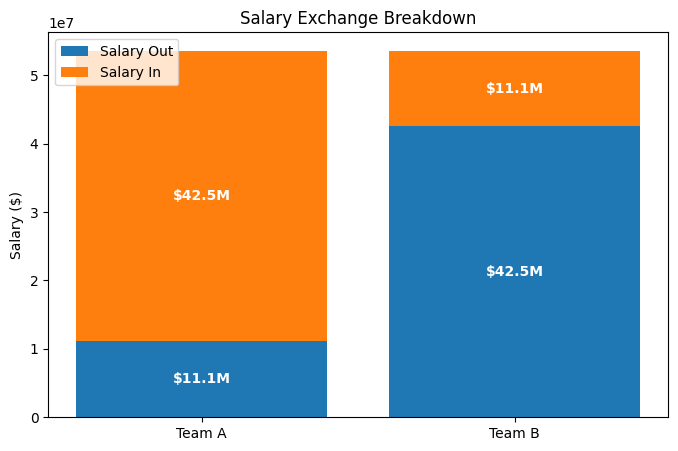

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

teams = ["Team A", "Team B"]

salary_out = [
    float(trade["teamA"]["salary_out"]),
    float(trade["teamB"]["salary_out"])
]

salary_in = [
    float(trade["teamA"]["salary_in"]),
    float(trade["teamB"]["salary_in"])
]

x = np.arange(len(teams))

plt.figure(figsize=(8,5))

# ---- Plot bars ----
bars_out = plt.bar(x, salary_out, label="Salary Out")
bars_in = plt.bar(x, salary_in, bottom=salary_out, label="Salary In")

# ---- Function to format salary in millions ----
def format_money(val):
    return f"${val/1_000_000:.1f}M"

# ---- Add labels for Salary Out ----
for bar in bars_out:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height/2,
        format_money(height),
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

# ---- Add labels for Salary In ----
for i, bar in enumerate(bars_in):
    height = bar.get_height()
    bottom = salary_out[i]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bottom + height/2,
        format_money(height),
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

# ---- Labels ----
plt.xticks(x, teams)
plt.ylabel("Salary ($)")
plt.title("Salary Exchange Breakdown")
plt.legend()

plt.show()

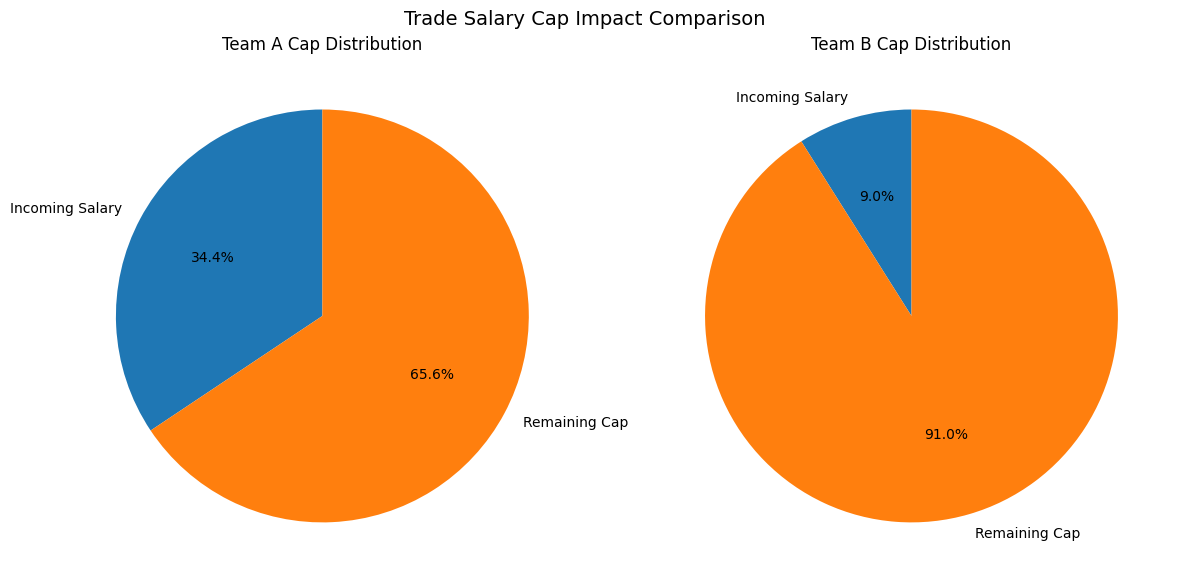

In [ ]:
import matplotlib.pyplot as plt

def plot_cap_distribution_comparison(trade_result, salary_df):
    """
    Plot side-by-side salary cap distribution for Team A and Team B.
    """

    # Get salary cap (same for league)
    salary_cap = float(salary_df["salary_cap"].iloc[0])

    # ---- Extract values ----
    teamA_in = float(trade_result["teamA"]["salary_in"])
    teamB_in = float(trade_result["teamB"]["salary_in"])

    teamA_remaining = max(salary_cap - teamA_in, 0)
    teamB_remaining = max(salary_cap - teamB_in, 0)

    # ---- Create figure with 2 plots ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Team A Pie
    axes[0].pie(
        [teamA_in, teamA_remaining],
        labels=["Incoming Salary", "Remaining Cap"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[0].set_title("Team A Cap Distribution")

    # Team B Pie
    axes[1].pie(
        [teamB_in, teamB_remaining],
        labels=["Incoming Salary", "Remaining Cap"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[1].set_title("Team B Cap Distribution")

    plt.suptitle("Trade Salary Cap Impact Comparison", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cap_distribution_comparison(trade, df)